# day-08-lora-from-scratch — worked solutions & answer key

Solutions to the exercises in [`../lesson.ipynb`](../lesson.ipynb), plus the self-check answer key. **Try each exercise yourself first** — the value is in the attempt, not the answer.

In [12]:
# ---- Solution 1 ----
def lora_params(d, layers, mats, r):
    return layers * mats * r * (d + d)
for r in (8, 16):
    p = lora_params(4096, 32, 2, r)
    print(f"S1: r={r:>2} -> {p:,} trainable ({100*p/7e9:.3f}% of 7B)")

S1: r= 8 -> 4,194,304 trainable (0.060% of 7B)
S1: r=16 -> 8,388,608 trainable (0.120% of 7B)


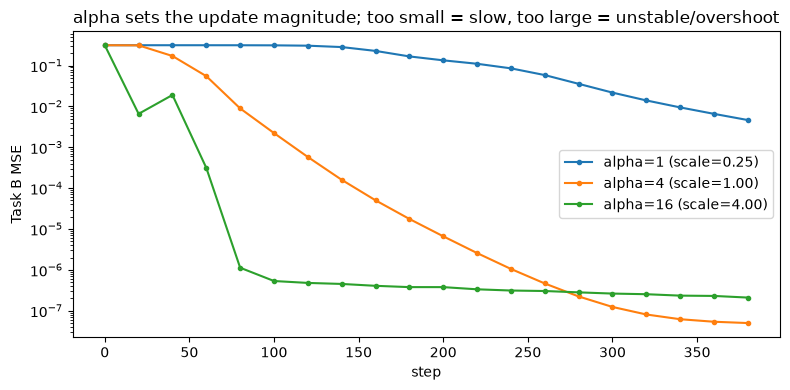

In [13]:
# ---- Solution 2 ----
plt.figure(figsize=(8,4))
for alpha in [1, 4, 16]:
    _,_,_,h = train_lora(r=4, alpha=alpha, steps=400)
    plt.plot(*zip(*h), marker=".", label=f"alpha={alpha} (scale={alpha/4:.2f})")
plt.yscale("log"); plt.legend(); plt.xlabel("step"); plt.ylabel("Task B MSE")
plt.title("alpha sets the update magnitude; too small = slow, too large = unstable/overshoot")
plt.tight_layout(); plt.show()

In [14]:
# ---- Solution 3 ----
def train_lora_randB(r=2, steps=400, lr=0.05, seed=0):
    g = np.random.default_rng(seed); scale = 1.0
    A = g.standard_normal((r, D_IN))*0.01
    B = g.standard_normal((D_HID, r))*0.01           # NOT zero
    for t in range(steps):
        x = g.standard_normal((256, D_IN)); tgt = task_B_target(x)
        w1e = W1 + scale*(B@A); z = x@w1e.T; h = np.maximum(0,z); pred = h@W2.T
        g_pred = 2*(pred-tgt)/x.shape[0]; g_z = (g_pred@W2)*(z>0); g_w1 = g_z.T@x
        B -= lr*scale*(g_w1@A.T); A -= lr*scale*(B.T@g_w1)
    return mse(model(Xte, W1+scale*(B@A), W2), task_B_target(Xte))

print(f"S3: random-B final MSE {train_lora_randB():.5f} (still converges).")
print("    Lost: at step 0 the model != the pretrained model, so the first eval/generation")
print("    before any training is already perturbed. Zero-B guarantees a clean starting point.")

S3: random-B final MSE 0.00000 (still converges).
    Lost: at step 0 the model != the pretrained model, so the first eval/generation
    before any training is already perturbed. Zero-B guarantees a clean starting point.


In [15]:
# ---- Solution 4 ----
def rebuild_taskB(true_rank):
    U = rng.standard_normal((D_HID, true_rank))/np.sqrt(true_rank)
    V = rng.standard_normal((true_rank, D_IN))/np.sqrt(D_IN)
    dW = 0.8*(U@V)
    return lambda x: model(x, W1+dW, W2), dW

tgt5, dW5 = rebuild_taskB(5)
globals()['task_B_target'] = tgt5           # point the trainer at the rank-5 task
print(f"{'rank':>4} {'MSE':>10}")
for r in [1,2,4,5,8,16]:
    A,B,s,_ = train_lora(r=r, steps=600)
    print(f"{r:>4} {mse(model(Xte, W1+s*(B@A), W2), tgt5(Xte)):>10.5f}")
print("S4: the plateau now starts around r=5 (the new true rank).")

rank        MSE
   1    0.20765
   2    0.12852


   4    0.02471
   5    0.00000
   8    0.00000


  16    0.00000
S4: the plateau now starts around r=5 (the new true rank).


### Solutions 5 & 6 (worked)

**S5 — QLoRA sketch:** quantizing the frozen base to int8 adds a small, roughly constant error
floor to every forward pass, so the adapter trains against a slightly noisy base and final MSE
rises a little (often a few %). The win: the *base* now takes ~1/4 (int8) or ~1/8 (int4) the
memory, and the fp16 adapter is unaffected — that's how a 65B model fine-tunes on a single
24–48 GB GPU. Try it:

```python
q = np.abs(W1).max() / 127
W1_q = np.round(W1 / q) * q
# then run train_lora but with W1 -> W1_q inside eff_w1()
```

**S6 — serving math:** adapter params per customer =
`40 layers × 2 mats × 16 × (5120 + 5120) = 40 × 2 × 16 × 10240 ≈ 13.1 M` params.
In fp16 that's ~26 MB. × 40 customers ≈ **1.05 GB**. Base is 26 GB. Total ≈ **27 GB** — all 40
fine-tunes fit alongside the base on one 40 GB GPU, vs `40 × 26 GB = 1.04 TB` for 40 full
fine-tunes.

### Answer key
1. ~16 bytes/param: fp16 weights (2) + fp16 grads (2) + fp32 Adam `m` (4) + fp32 Adam `v` (4)
   + often an fp32 master weight copy (4). The optimizer state dominates.
2. `W' = W + (alpha/r)·B·A`, with `A ∈ R^{r×d_in}`, `B ∈ R^{d_out×r}`. Only `A` and `B` are
   trained; `W` is frozen.
3. So that `B·A = 0` at step 0 and the adapted model is exactly the pretrained model — no
   perturbation before any training, and a clean, reversible starting point.
4. Underfitting: the loss plateaus above what `r ≥ 4` achieves, because a rank-1 product
   cannot represent a rank-4 update.
5. Merged: no — it's folded into `W`, identical shape, one matmul. Unmerged: a tiny amount —
   one extra skinny matmul (`x·Aᵀ` then `·Bᵀ`), negligible but nonzero.
6. (a) The update is low-rank and small-norm, so most of the weight space is untouched;
   (b) it's additive and reversible — drop the adapter and the base is bit-for-bit back.
   (Also: far fewer trainable params → less capacity to overwrite pretrained features.)
7. QLoRA quantizes the frozen base to 4-bit (from fp16) while keeping the LoRA adapter in
   fp16. It buys a ~4× smaller base in memory, letting much larger models be fine-tuned on a
   single GPU, at the cost of a small quantization-error floor.